# AI Agents for Corporate Valuation & Financial Modelling

**Authors:** Kate Lawal · Nathan Burns · Isijola Olufemi · Kundan Singh

**GitHub:** [Agents for Corporate Valuation and Financial Modelling](https://github.com/Katredandred/Agents-for-Corporate-Valuation-and-Financial-modelling/tree/main)

**Model:** Google Gemini 2.5 Flash via smolagents

---

## Overview

This chapter explores how we can apply the **LLM multi-agentic framework** for the topic of
**corporate valuation and financial modelling**, using the business case of a **buy-side analyst
at an asset management firm who must evaluate whether a public company is fairly priced before
a potential equity investment**.

Traditionally, this analyst spends hours in Excel — pulling financial statements, hard-coding
DCF models, manually updating sensitivity tables. Every assumption change means re-entering
formulas. Every new company means starting over.

We replace that entire workflow with a **suite of 12 agentic tools** that the analyst can
query in plain English. Each tool encodes one discrete financial concept. Two orchestrated
agents combine them to produce a complete investment analysis in seconds.

```
┌────────────────────────────────────────────────────────────────────┐
│              THE CORPORATE VALUATION AGENT PIPELINE                 │
│                                                                     │
│  ANALYST: "Give me a full valuation memo on Apple."                │
│                                                                     │
│  AGENT 1 — Fundamental Analyst:                                     │
│  ① fetch_and_summarise_financials  (EDA · descriptive stats)       │
│  ② plot_revenue_and_margins        (Visualisation)                 │
│  ③ calculate_profitability_ratios  (Ratios)                        │
│  ④ calculate_liquidity_leverage    (Ratios · risk flags)           │
│  ⑨ calculate_altman_zscore         (Score · distress prediction)   │
│  ⑩ comparable_company_analysis     (EDA · peer multiples)         │
│  ⑪ calculate_moving_averages       (Moving averages · trend)       │
│                                                                     │
│  AGENT 2 — Valuation Modeller:                                      │
│  ⑤ calculate_capm_wacc             (Calculation · CAPM)            │
│  ⑥ run_dcf_model                   (Predictive · DCF)              │
│  ⑦ run_sensitivity_analysis        (Scenario · WACC×TGR matrix)    │
│  ⑧ forecast_revenue_regression     (Predictive · linear regression)│
│  ⑫ generate_investment_memo        (Orchestration · full memo)     │
│                                                                     │
│  OUTPUT: Structured investment memo · BUY / HOLD / SELL signal     │
└────────────────────────────────────────────────────────────────────┘
```

---

## Business Concepts Covered (12 Tools)

| # | Tool | Concept | Type |
|---|------|---------|------|
| 1 | `fetch_and_summarise_financials` | Financial statement EDA | EDA · Descriptive stats |
| 2 | `plot_revenue_and_margins` | Revenue & margin trend | Visualisation |
| 3 | `calculate_profitability_ratios` | Gross/net margin, ROE, ROA | Ratios |
| 4 | `calculate_liquidity_leverage` | Current ratio, D/E, coverage | Ratios |
| 5 | `calculate_capm_wacc` | Cost of equity & WACC | Calculation |
| 6 | `run_dcf_model` | 5-year DCF intrinsic value | Predictive analytics |
| 7 | `run_sensitivity_analysis` | WACC × TGR matrix | Scenario analysis |
| 8 | `forecast_revenue_regression` | Linear regression forecast | Predictive analytics |
| 9 | `calculate_altman_zscore` | Financial distress score | Score |
| 10 | `comparable_company_analysis` | Peer multiples comps | EDA · Ratios |
| 11 | `calculate_moving_averages` | 50/200-day MA trend | Moving averages |
| 12 | `generate_investment_memo` | Full investment memo | Orchestration |


---

## Setup

Run this cell once. Restart runtime if prompted.

In [ ]:
!pip install smolagents yfinance pandas numpy matplotlib scipy gradio pillow -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
from smolagents import CodeAgent, tool
from smolagents import OpenAIServerModel
from smolagents.monitoring import LogLevel
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from PIL import Image
import io, json, warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported.")


✅ All libraries imported.


### API Key & Model

Get a free Gemini API key at https://aistudio.google.com/app/apikey


 Colab Secrets (key name: `GEMINI_API_KEY`):

In [ ]:
from google.colab import userdata
API_KEY = userdata.get("GEMINI_API_KEY")


In [ ]:
# Initialise model — Gemini 2.5 Flash via OpenAI-compatible endpoint
model = OpenAIServerModel(
    model_id="gemini-2.5-flash",
    api_base="https://generativelanguage.googleapis.com/v1beta/openai/",
    api_key=API_KEY,
)
print("✅ Model initialised: gemini-2.5-flash")


NameError: name 'API_KEY' is not defined

---

# Part 1: The 12 Business Concept Tools

Each tool encodes one financial concept. We follow three key principles:

**Principle 1: Clear "When to Use" Docstrings** — the docstring is the agent's instruction manual.

**Principle 2: Type Hints Matter** — `ticker: str` and `-> str` tell the model what goes in and out.

**Principle 3: One Tool, One Job** — each tool does one thing precisely; the agent combines them.


---

## Tool 1: Financial Statement Summary (Exploratory Data Analysis)

**Concept:** Before any valuation, the analyst reads the financial statements. This EDA step
surfaces headline numbers, runs descriptive statistics on the revenue trend, and flags
the raw inputs needed by all downstream tools.

**Traditional approach:** Download 10-K from SEC EDGAR, copy-paste into Excel, manually format.


In [1]:
@tool
def fetch_and_summarise_financials(ticker: str) -> str:
    """
    Fetches and summarises key financial statement data for a company.
    Use this as the FIRST step in any valuation — it provides the raw inputs
    (revenue, FCF, debt, cash, shares) needed by all downstream tools.
    Returns descriptive statistics and a structured JSON summary.

    Args:
        ticker: Stock ticker symbol (e.g. 'AAPL', 'MSFT', 'TSLA')

    Returns:
        JSON string with income statement, balance sheet, and cash flow highlights
        plus descriptive statistics (mean, std, min, max) for the revenue trend.
    """
    try:                                                          # Fix 2: wrap in try/except
        stock = yf.Ticker(ticker.upper())
        info  = stock.info
        cf    = stock.cashflow
        inc   = stock.income_stmt
        # Fix 1: removed unused `bal = stock.balance_sheet`

        # Revenue trend — last 4 years using a loop
        revenue_series = {}
        if 'Total Revenue' in inc.index:
            for col in inc.columns[:4]:
                year = str(col.year)                              # Fix 4: .year not string slice
                revenue_series[year] = round(inc.loc['Total Revenue', col] / 1e9, 2)

        rev_vals = list(revenue_series.values())

        # Descriptive statistics using pandas — Fix 3: guard against empty rev_vals
        rev_df = pd.Series(rev_vals)
        if len(rev_vals) >= 2:
            rev_stats = {
                "mean_B":  round(rev_df.mean(), 2),
                "std_B":   round(rev_df.std(),  2),
                "min_B":   round(rev_df.min(),  2),
                "max_B":   round(rev_df.max(),  2),
                "growth_pct_latest": round(
                    (rev_vals[0] - rev_vals[1]) / rev_vals[1] * 100, 1
                )
            }
        else:
            rev_stats = {
                "mean_B": None, "std_B": None,
                "min_B":  None, "max_B": None,
                "growth_pct_latest": None
            }

        # FCF = Operating CF + Capex (capex is negative in yfinance)
        op_cf = cf.loc['Operating Cash Flow'].iloc[0] if 'Operating Cash Flow' in cf.index else 0
        capex = cf.loc['Capital Expenditure'].iloc[0]  if 'Capital Expenditure'  in cf.index else 0
        fcf   = round((op_cf + capex) / 1e9, 2)

        net_income = round(inc.loc['Net Income'].iloc[0] / 1e9, 2) if 'Net Income' in inc.index else None

        # Fix 5: use 0 fallback (not 1) and collect data warnings
        shares_raw = info.get('sharesOutstanding') or 0
        warnings_list = []
        if shares_raw == 0:
            warnings_list.append("sharesOutstanding missing — per-share values unreliable")

        result = {
            "ticker":                    ticker.upper(),
            "company_name":              info.get('longName', ticker),
            "sector":                    info.get('sector', 'N/A'),
            "industry":                  info.get('industry', 'N/A'),
            "revenue_by_year_B":         revenue_series,
            "revenue_descriptive_stats": rev_stats,
            "free_cash_flow_ttm_B":      fcf,
            "net_income_ttm_B":          net_income,
            "total_debt_B":              round((info.get('totalDebt',         0) or 0) / 1e9, 2),
            "cash_B":                    round((info.get('totalCash',         0) or 0) / 1e9, 2),
            "shares_outstanding_B":      round(shares_raw / 1e9, 4),
            "current_price":             round(info.get('currentPrice', 0)   or 0, 2),
            "market_cap_B":              round((info.get('marketCap',         0) or 0) / 1e9, 2),
            "beta":                      round(info.get('beta', 1.0)          or 1.0, 2),
            "ebitda_B":                  round((info.get('ebitda',            0) or 0) / 1e9, 2),
            "data_warnings":             warnings_list,
        }
        return json.dumps(result, indent=2)

    except Exception as e:                                        # Fix 2: return error as JSON
        return json.dumps({
            "error": True,
            "ticker": ticker.upper(),
            "message": f"Failed to fetch data: {str(e)}"
        })

print("Tool 1: fetch_and_summarise_financials")
data = json.loads(fetch_and_summarise_financials("AAPL"))
if data.get("error"):
    print(f"  ERROR: {data['message']}")
else:
    print(f"  {data['company_name']} | Revenue stats: {data['revenue_descriptive_stats']}")
    if data["data_warnings"]:
        print(f"  Warnings: {data['data_warnings']}")

NameError: name 'tool' is not defined

---

## Tool 2: Revenue & Margin Trend Plot (Visualisation / EDA)

**Concept:** Margin compression or expansion over time is one of the most important signals
in equity analysis. This tool plots revenue bars and margin lines on a dual-axis chart.

**Key programming concepts:** `for` loop over years, `if-then` check for missing data,
`PIL.Image` + `IPython.display` for inline rendering inside a `@tool` function.


In [ ]:
@tool
def plot_revenue_and_margins(ticker: str) -> str:
    """
    Plots a dual-axis chart: revenue bars (left axis) and gross/operating
    margin lines (right axis) over the last 4 fiscal years.
    Use this for the EDA visualisation step — to spot revenue and margin trends
    before building a model. Displays the chart inline and returns a text summary.

    Args:
        ticker: Stock ticker symbol (e.g. 'AAPL', 'MSFT', 'TSLA')

    Returns:
        A text summary of the revenue and margin trend.
    """
    from IPython.display import display as ipy_display

    try:                                                              # Fix 3: wrap in try/except
        stock = yf.Ticker(ticker.upper())
        inc   = stock.income_stmt

        # Fix 1: check for Total Revenue ONCE before the loop, return early if missing
        if 'Total Revenue' not in inc.index:
            return json.dumps({
                "error": True,
                "ticker": ticker.upper(),
                "message": "Total Revenue not found in income statement"
            })

        years, revenues, gross_margins, op_margins = [], [], [], []

        for col in reversed(inc.columns[:4]):                         # loop: iterate fiscal years
            year = str(col.year)                                      # Fix 4: .year not string slice
            rev  = inc.loc['Total Revenue', col]
            if rev == 0 or pd.isna(rev):                              # Fix 2: NaN guard added
                continue
            years.append(year)
            revenues.append(rev / 1e9)
            gm = inc.loc['Gross Profit',     col] / rev * 100 if 'Gross Profit'     in inc.index else None
            om = inc.loc['Operating Income', col] / rev * 100 if 'Operating Income' in inc.index else None
            gross_margins.append(gm)
            op_margins.append(om)

        fig, ax1 = plt.subplots(figsize=(9, 5))
        ax2 = ax1.twinx()

        ax1.bar(years, revenues, color='#1C7293', alpha=0.75, label='Revenue (B)')
        ax1.set_ylabel('Revenue (USD Billions)', color='#1C7293', fontsize=11)
        ax1.tick_params(axis='y', labelcolor='#1C7293')
        ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fB'))

        if any(m is not None for m in gross_margins):
            ax2.plot(years, gross_margins, 'o-', color='#F4A261', lw=2.5, label='Gross Margin %')
        if any(m is not None for m in op_margins):
            ax2.plot(years, op_margins,    's-', color='#2A9D8F', lw=2.5, label='Operating Margin %')

        ax2.set_ylabel('Margin (%)', fontsize=11)
        ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
        plt.title(f'{ticker.upper()} — Revenue & Margin Trend', fontsize=13, fontweight='bold', pad=12)
        plt.tight_layout()

        buf = io.BytesIO()
        plt.savefig(buf, format='png', dpi=120)
        buf.seek(0)
        ipy_display(Image.open(buf))
        plt.close()                                                   # Fix 3: always reached in happy path

        if len(gross_margins) >= 2 and gross_margins[-1] and gross_margins[0]:
            direction = 'expanded' if gross_margins[-1] > gross_margins[0] else 'compressed'
            return (f'Gross margin {direction} from {gross_margins[0]:.1f}% to '
                    f'{gross_margins[-1]:.1f}% over {len(years)} years. '
                    f'Revenue grew from ${revenues[0]:.1f}B to ${revenues[-1]:.1f}B.')
        return f'Revenue trend plotted for {len(years)} years.'

    except Exception as e:                                            # Fix 3: close figure & return error
        plt.close('all')
        return json.dumps({
            "error": True,
            "ticker": ticker.upper(),
            "message": f"Failed to plot revenue and margins: {str(e)}"
        })

print("Tool 2: plot_revenue_and_margins")
print(plot_revenue_and_margins("AAPL"))

---

## Tool 3: Profitability Ratios (Ratios)

**Concept:** Profitability ratios measure how efficiently a company converts revenue into profit.

```
ROE = Net Income / Shareholders' Equity
ROA = Net Income / Total Assets
Net Margin = Net Income / Revenue
```


In [ ]:
@tool
def calculate_profitability_ratios(ticker: str) -> str:
    """
    Calculates key profitability ratios: gross margin, operating margin,
    net margin, ROE, and ROA. Use this after fetching financials to assess
    earnings quality before running a DCF model.

    Args:
        ticker: Stock ticker symbol

    Returns:
        JSON string with profitability ratios and interpretation flags.
    """
    try:                                                              # Fix 3: wrap in try/except
        stock = yf.Ticker(ticker.upper())
        inc   = stock.income_stmt
        bal   = stock.balance_sheet

        # Fix 1: None fallback instead of 1; early return if revenue missing
        if 'Total Revenue' not in inc.index:
            return json.dumps({"error": True, "ticker": ticker.upper(),
                               "message": "Total Revenue missing — cannot calculate margins"})
        rev = inc.loc['Total Revenue'].iloc[0]
        if rev is None or pd.isna(rev) or rev == 0:
            return json.dumps({"error": True, "ticker": ticker.upper(),
                               "message": "Total Revenue is zero or NaN — cannot calculate margins"})

        # Fix 2: is not None checks instead of truthiness throughout
        gp      = inc.loc['Gross Profit'].iloc[0]        if 'Gross Profit'        in inc.index else None
        op_inc  = inc.loc['Operating Income'].iloc[0]    if 'Operating Income'    in inc.index else None
        net_inc = inc.loc['Net Income'].iloc[0]           if 'Net Income'          in inc.index else None
        equity  = bal.loc['Stockholders Equity'].iloc[0] if 'Stockholders Equity' in bal.index else None
        assets  = bal.loc['Total Assets'].iloc[0]        if 'Total Assets'        in bal.index else None

        gross_margin = round(gp      / rev * 100, 1) if gp      is not None else None
        op_margin    = round(op_inc  / rev * 100, 1) if op_inc  is not None else None
        net_margin   = round(net_inc / rev * 100, 1) if net_inc is not None else None
        roe = round(net_inc / equity * 100, 1) if (net_inc is not None and equity is not None and equity != 0) else None
        roa = round(net_inc / assets * 100, 1) if (net_inc is not None and assets is not None and assets != 0) else None

        flags = []
        # Fix 4: is not None instead of truthiness in flag conditions
        if net_margin is not None and net_margin > 20:   flags.append("HIGH_NET_MARGIN: exceptional profitability")
        elif net_margin is not None and net_margin < 5:  flags.append("LOW_NET_MARGIN: thin margins — watch cost pressures")
        if roe is not None and roe > 30:                 flags.append("HIGH_ROE: strong shareholder returns")
        elif roe is not None and roe < 10:               flags.append("LOW_ROE: below typical equity hurdle rate")

        return json.dumps({
            "ticker":               ticker.upper(),
            "gross_margin_pct":     gross_margin,
            "operating_margin_pct": op_margin,
            "net_margin_pct":       net_margin,
            "roe_pct":              roe,
            "roa_pct":              roa,
            "interpretation":       flags if flags else ["Ratios within normal range."],
        }, indent=2)

    except Exception as e:                                            # Fix 3: return error as JSON
        return json.dumps({"error": True, "ticker": ticker.upper(),
                           "message": f"Failed to fetch data: {str(e)}"})

print("Tool 3: calculate_profitability_ratios")
result = json.loads(calculate_profitability_ratios("AAPL"))
if result.get("error"):
    print(f"  ERROR: {result['message']}")
else:
    print(f"  Net margin: {result['net_margin_pct']}% | ROE: {result['roe_pct']}%")
    print(f"  Flags: {result['interpretation']}")

---

## Tool 4: Liquidity & Leverage Ratios (Ratios)

**Concept:** A company with great earnings can still fail if it runs out of cash.

```
Current Ratio   = Current Assets / Current Liabilities
Debt-to-Equity  = Total Debt / Shareholders' Equity
Interest Coverage = EBIT / Interest Expense
```


In [ ]:
@tool
def calculate_liquidity_leverage(ticker: str) -> str:
    """
    Calculates liquidity ratios (current ratio, quick ratio) and leverage ratios
    (debt-to-equity, net debt, interest coverage). Use this to assess financial
    health and solvency risk before including a company in a DCF valuation.

    Args:
        ticker: Stock ticker symbol

    Returns:
        JSON string with liquidity and leverage ratios plus risk flags.
    """
    try:                                                                   # Fix 2: wrap in try/except
        stock = yf.Ticker(ticker.upper())
        info  = stock.info
        bal   = stock.balance_sheet
        inc   = stock.income_stmt

        curr_assets = bal.loc['Current Assets'].iloc[0]      if 'Current Assets'      in bal.index else None
        curr_liab   = bal.loc['Current Liabilities'].iloc[0] if 'Current Liabilities' in bal.index else None
        inventory   = bal.loc['Inventory'].iloc[0]           if 'Inventory'           in bal.index else 0
        total_debt  = (info.get('totalDebt', 0) or 0) / 1e9
        cash        = (info.get('totalCash', 0) or 0) / 1e9
        equity      = bal.loc['Stockholders Equity'].iloc[0] if 'Stockholders Equity' in bal.index else None
        ebit        = inc.loc['Operating Income'].iloc[0]    if 'Operating Income'    in inc.index else None
        interest    = inc.loc['Interest Expense'].iloc[0]    if 'Interest Expense'    in inc.index else None

        # Fix 1: is not None checks + explicit zero-denominator guards
        current_ratio = round(curr_assets / curr_liab, 2) \
            if (curr_assets is not None and curr_liab is not None and curr_liab != 0) else None
        quick_ratio   = round((curr_assets - inventory) / curr_liab, 2) \
            if (curr_assets is not None and curr_liab is not None and curr_liab != 0) else None
        de_ratio      = round(total_debt / (equity / 1e9), 2) \
            if (equity is not None and equity != 0) else None
        net_debt      = round(total_debt - cash, 2)
        int_coverage  = round(ebit / abs(interest), 2) \
            if (ebit is not None and interest is not None and interest != 0) else None

        flags = []
        # Fix 3: is not None instead of truthiness in all flag conditions
        if current_ratio is not None and current_ratio < 1.0:  flags.append("LIQUIDITY_RISK: current ratio below 1x")
        if de_ratio is not None and de_ratio > 2.0:            flags.append("HIGH_LEVERAGE: D/E above 2x")
        if int_coverage is not None and int_coverage < 3.0:    flags.append("COVERAGE_RISK: interest coverage below 3x")

        return json.dumps({
            "ticker":            ticker.upper(),
            "current_ratio":     current_ratio,
            "quick_ratio":       quick_ratio,
            "debt_to_equity":    de_ratio,
            "net_debt_B":        net_debt,
            "interest_coverage": int_coverage,
            "risk_flags":        flags if flags else ["No major liquidity or leverage concerns."],
        }, indent=2)

    except Exception as e:                                                 # Fix 2: return error as JSON
        return json.dumps({"error": True, "ticker": ticker.upper(),
                           "message": f"Failed to fetch data: {str(e)}"})

print("Tool 4: calculate_liquidity_leverage")
result = json.loads(calculate_liquidity_leverage("AAPL"))
if result.get("error"):
    print(f"  ERROR: {result['message']}")
else:
    print(f"  Current ratio: {result['current_ratio']} | D/E: {result['debt_to_equity']} | Coverage: {result['interest_coverage']}")
    print(f"  Flags: {result['risk_flags']}")

---

## Tool 5: CAPM Cost of Equity & WACC (Calculation)

**Concept:** WACC is the discount rate in the DCF model. We derive it from the company's
specific risk profile using CAPM:

```
Cost of Equity = Risk-Free Rate + Beta × Equity Risk Premium
WACC = (E/V) × Cost of Equity + (D/V) × Cost of Debt × (1 − Tax Rate)
```


In [ ]:
@tool
def calculate_capm_wacc(
    ticker: str,
    risk_free_rate: float = 0.045,
    equity_risk_premium: float = 0.055,
    tax_rate: float = 0.21,
    cost_of_debt: float = None,
) -> str:
    """
    Calculates cost of equity via CAPM and the blended WACC.
    Use this BEFORE running the DCF model — WACC is the discount rate.
    If cost_of_debt is not provided, it is estimated from yfinance interest expense data.

    Args:
        ticker:               Stock ticker symbol
        risk_free_rate:       Annual risk-free rate as decimal (default 0.045 = 4.5%)
        equity_risk_premium:  Market equity risk premium as decimal (default 0.055 = 5.5%)
        tax_rate:             Marginal corporate tax rate (default 0.21 = 21%)
        cost_of_debt:         Pre-tax cost of debt as decimal; if None it is estimated

    Returns:
        JSON string with CAPM inputs, cost of equity, cost of debt, and blended WACC.
    """
    COD_CAP = 0.30    # Fix 2: 30% upper bound on estimated cost of debt

    try:                                                                   # Fix 1: wrap in try/except
        stock = yf.Ticker(ticker.upper())
        info  = stock.info
        inc   = stock.income_stmt

        # Fix 3a: flag when beta is missing and default is used
        warnings = []
        beta_raw = info.get('beta')
        if beta_raw is None or beta_raw == 0:
            warnings.append("beta not available — defaulted to 1.0 (market risk)")
            beta = 1.0
        else:
            beta = float(beta_raw)

        market_cap = (info.get('marketCap', 0) or 0) / 1e9
        total_debt = (info.get('totalDebt',  0) or 0) / 1e9

        cost_of_equity = risk_free_rate + beta * equity_risk_premium

        # Estimate cost of debt if not provided
        if cost_of_debt is None:
            if 'Interest Expense' in inc.index and total_debt > 0:
                interest_exp = abs(inc.loc['Interest Expense'].iloc[0]) / 1e9
                raw_cod = interest_exp / total_debt
                if raw_cod > COD_CAP:                                      # Fix 2: cap absurd estimates
                    warnings.append(
                        f"Estimated cost_of_debt={raw_cod*100:.1f}% exceeds cap — "
                        f"clamped to {COD_CAP*100:.0f}%. Check interest expense data."
                    )
                    cost_of_debt = COD_CAP
                else:
                    cost_of_debt = raw_cod
                warnings.append(                                           # Fix 3b: flag estimation
                    f"cost_of_debt estimated from income statement ({cost_of_debt*100:.2f}%) "
                    f"— pass cost_of_debt explicitly for higher accuracy"
                )
            else:
                cost_of_debt = 0.05
                warnings.append("cost_of_debt not estimable — defaulted to 5.0%")

        after_tax_kd  = cost_of_debt * (1 - tax_rate)
        total_capital = market_cap + total_debt
        weight_equity = market_cap  / total_capital if total_capital > 0 else 1.0
        weight_debt   = total_debt  / total_capital if total_capital > 0 else 0.0
        wacc          = weight_equity * cost_of_equity + weight_debt * after_tax_kd

        return json.dumps({
            "ticker":                    ticker.upper(),
            "beta":                      round(beta, 2),
            "risk_free_rate_pct":        round(risk_free_rate       * 100, 2),
            "equity_risk_premium_pct":   round(equity_risk_premium  * 100, 2),
            "cost_of_equity_pct":        round(cost_of_equity       * 100, 2),
            "cost_of_debt_pretax_pct":   round(cost_of_debt         * 100, 2),
            "cost_of_debt_aftertax_pct": round(after_tax_kd         * 100, 2),
            "weight_equity_pct":         round(weight_equity         * 100, 1),
            "weight_debt_pct":           round(weight_debt           * 100, 1),
            "wacc_pct":                  round(wacc                  * 100, 2),
            "data_warnings":             warnings,
            "note": "WACC derived from CAPM + market capital structure. Use as DCF discount rate.",
        }, indent=2)

    except Exception as e:                                                 # Fix 1: return error as JSON
        return json.dumps({"error": True, "ticker": ticker.upper(),
                           "message": f"Failed to fetch data: {str(e)}"})

print("Tool 5: calculate_capm_wacc")
result = json.loads(calculate_capm_wacc("AAPL"))
if result.get("error"):
    print(f"  ERROR: {result['message']}")
else:
    print(f"  WACC: {result['wacc_pct']}% | Cost of equity: {result['cost_of_equity_pct']}%")
    if result["data_warnings"]:
        print(f"  Warnings: {result['data_warnings']}")

---

## Tool 6: DCF Valuation Model (Predictive Analytics)

**Concept:** The DCF model is the cornerstone of intrinsic valuation.

```
Enterprise Value = Σ [FCFₜ / (1+WACC)ᵗ]  +  Terminal Value / (1+WACC)⁵
Terminal Value   = FCF₅ × (1+TGR) / (WACC − TGR)     ← Gordon Growth Model
Intrinsic Value  = (EV − Net Debt) / Shares Outstanding
```


In [ ]:
@tool
def run_dcf_model(
    ticker: str,
    wacc: float = 0.10,
    terminal_growth_rate: float = 0.025,
    fcf_growth_y1_3: float = 0.12,
    fcf_growth_y4_5: float = 0.07,
) -> str:
    """
    Runs a 5-year Discounted Cash Flow (DCF) valuation model.
    Projects FCF using two-stage growth, discounts at WACC, adds a Gordon Growth
    terminal value, and derives intrinsic value per share.
    Returns BUY if intrinsic > price by more than 10%, SELL if less than -10%, else HOLD.

    Args:
        ticker:               Stock ticker symbol
        wacc:                 Discount rate as decimal (e.g. 0.10 = 10%)
        terminal_growth_rate: Perpetuity growth rate (e.g. 0.025 = 2.5%)
        fcf_growth_y1_3:      FCF growth rate for years 1 to 3 (default 0.12)
        fcf_growth_y4_5:      FCF growth rate for years 4 to 5 (default 0.07)

    Returns:
        JSON string with full DCF output, intrinsic value per share, and BUY/HOLD/SELL signal.
    """
    try:                                                                   # Fix 2: wrap in try/except
        stock = yf.Ticker(ticker.upper())
        info  = stock.info
        cf    = stock.cashflow

        # Fix 3: WACC guard is the very first check — before any computation
        if wacc <= terminal_growth_rate:
            return json.dumps({
                "error": True, "ticker": ticker.upper(),
                "message": f"WACC ({wacc*100:.1f}%) must exceed terminal growth rate ({terminal_growth_rate*100:.1f}%)"
            })

        warnings = []

        op_cf    = cf.loc['Operating Cash Flow'].iloc[0] if 'Operating Cash Flow' in cf.index else 0
        capex    = cf.loc['Capital Expenditure'].iloc[0]  if 'Capital Expenditure'  in cf.index else 0
        base_fcf = (op_cf + capex) / 1e9
        debt     = (info.get('totalDebt', 0) or 0) / 1e9
        cash_val = (info.get('totalCash', 0) or 0) / 1e9

        # Fix 1: shares fallback of 0 with early return instead of silent fallback of 1
        shares_raw = info.get('sharesOutstanding') or 0
        if shares_raw == 0:
            return json.dumps({
                "error": True, "ticker": ticker.upper(),
                "message": "sharesOutstanding missing — cannot compute intrinsic value per share"
            })
        shares = shares_raw / 1e9

        # Fix 5: missing price flagged — not silently used as 0
        price = info.get('currentPrice') or 0
        if price == 0:
            warnings.append("currentPrice missing — upside% and signal are unreliable")

        # Fix 4: negative base FCF flagged before projections
        if base_fcf <= 0:
            warnings.append(
                f"base_fcf={base_fcf:.2f}B is negative — DCF assumes growing FCF; "
                f"results may not be meaningful for this company"
            )

        # Loop to project FCF over 5 years with two-stage growth
        projected_fcf, pv_fcfs = [], []
        fcf = base_fcf
        for yr in range(1, 6):
            g   = fcf_growth_y1_3 if yr <= 3 else fcf_growth_y4_5   # if-then: growth stage
            fcf = fcf * (1 + g)
            projected_fcf.append(round(fcf, 3))
            pv_fcfs.append(round(fcf / (1 + wacc) ** yr, 3))

        tv       = projected_fcf[-1] * (1 + terminal_growth_rate) / (wacc - terminal_growth_rate)
        pv_tv    = tv / (1 + wacc) ** 5
        ev       = sum(pv_fcfs) + pv_tv
        equity_v = ev - debt + cash_val
        iv       = round(equity_v / shares, 2)
        upside   = round((iv - price) / price * 100, 1) if price else None   # Fix 5: None not 0
        signal   = ("BUY" if upside > 10 else ("SELL" if upside < -10 else "HOLD")) if upside is not None else "N/A"

        return json.dumps({
            "ticker":                    ticker.upper(),
            "base_fcf_B":                round(base_fcf, 2),
            "projected_fcf_B":           projected_fcf,
            "pv_fcfs_B":                 pv_fcfs,
            "pv_terminal_value_B":       round(pv_tv, 2),
            "enterprise_value_B":        round(ev, 2),
            "equity_value_B":            round(equity_v, 2),
            "intrinsic_value_per_share": iv,
            "current_market_price":      round(price, 2),
            "upside_downside_pct":       upside,
            "signal":                    signal,
            "data_warnings":             warnings,
            "assumptions": {
                "wacc":            f"{wacc*100:.1f}%",
                "terminal_growth": f"{terminal_growth_rate*100:.1f}%",
                "fcf_growth_y1_3": f"{fcf_growth_y1_3*100:.1f}%",
                "fcf_growth_y4_5": f"{fcf_growth_y4_5*100:.1f}%",
            },
        }, indent=2)

    except Exception as e:                                                 # Fix 2: return error as JSON
        return json.dumps({"error": True, "ticker": ticker.upper(),
                           "message": f"Failed to fetch data: {str(e)}"})

print("Tool 6: run_dcf_model")
r = json.loads(run_dcf_model("AAPL"))
if r.get("error"):
    print(f"  ERROR: {r['message']}")
else:
    print(f"  AAPL intrinsic value: ${r['intrinsic_value_per_share']} | Signal: {r['signal']}")
    if r["data_warnings"]:
        print(f"  Warnings: {r['data_warnings']}")

---

## Tool 7: Sensitivity Analysis — WACC × TGR Matrix (Scenario Analysis)

**Concept:** A single DCF output implies false precision. Professional analysts always
deliver a *range* of intrinsic values. This tool builds the standard WACC × TGR sensitivity
table used in investment banking pitch books.

**Key programming concept:** Nested `for` loops to build the matrix.


In [ ]:
@tool
def run_sensitivity_analysis(
    ticker: str,
    wacc_center: float = 0.10,
    tgr_center: float = 0.025,
) -> str:
    """
    Builds a 5x4 sensitivity matrix of intrinsic values per share across
    WACC and terminal growth rate combinations centred on the base case.
    Use this after run_dcf_model to bracket bull, base, and bear scenarios.

    Args:
        ticker:      Stock ticker symbol
        wacc_center: Base case WACC as decimal (default 0.10)
        tgr_center:  Base case terminal growth rate as decimal (default 0.025)

    Returns:
        JSON string with the full sensitivity matrix and scenario interpretation.
    """
    stock = yf.Ticker(ticker.upper())
    info  = stock.info
    cf    = stock.cashflow

    op_cf    = cf.loc['Operating Cash Flow'].iloc[0] if 'Operating Cash Flow' in cf.index else 0
    capex    = cf.loc['Capital Expenditure'].iloc[0]  if 'Capital Expenditure'  in cf.index else 0
    base_fcf = (op_cf + capex) / 1e9
    debt     = (info.get('totalDebt',         0) or 0) / 1e9
    cash_val = (info.get('totalCash',         0) or 0) / 1e9
    shares   = (info.get('sharesOutstanding', 1) or 1) / 1e9
    price    = info.get('currentPrice', 0) or 0

    wacc_range = [round(wacc_center + d, 3) for d in [-0.02, -0.01, 0, 0.01, 0.02]]
    tgr_range  = [round(tgr_center  + d, 3) for d in [-0.01, 0, 0.01, 0.02]]

    # Nested loop to populate the matrix
    matrix = {}
    for wacc in wacc_range:
        row = {}
        for tgr in tgr_range:
            if wacc <= tgr:           # if-then: Gordon Growth model undefined
                row[f"{tgr*100:.1f}%"] = "N/A"
                continue
            fcf, pv_fcfs = base_fcf, []
            for yr in range(1, 6):
                fcf *= (1 + (0.12 if yr <= 3 else 0.07))
                pv_fcfs.append(fcf / (1 + wacc) ** yr)
            tv = fcf * (1 + tgr) / (wacc - tgr)
            ev = sum(pv_fcfs) + tv / (1 + wacc) ** 5
            iv = round((ev - debt + cash_val) / shares, 2) if shares > 0 else 0
            row[f"{tgr*100:.1f}%"] = iv
        matrix[f"{wacc*100:.1f}%"] = row

    base_iv  = matrix.get(f"{wacc_center*100:.1f}%", {}).get(f"{tgr_center*100:.1f}%", "N/A")
    bull_iv  = list(list(matrix.values())[0].values())[-1]
    bear_iv  = list(list(matrix.values())[-1].values())[0]

    return json.dumps({
        "ticker":               ticker.upper(),
        "current_price":        round(price, 2),
        "base_wacc":            f"{wacc_center*100:.1f}%",
        "base_tgr":             f"{tgr_center*100:.1f}%",
        "base_case_iv":         base_iv,
        "sensitivity_matrix":   matrix,
        "interpretation": (
            f"Base case IV=${base_iv} vs market ${round(price,2)}. "
            f"Bull case IV=${bull_iv}. Bear case IV=${bear_iv}."
        ),
    }, indent=2)

print("Tool 7: run_sensitivity_analysis")
s = json.loads(run_sensitivity_analysis("AAPL"))
print(f"  {s['interpretation']}")


Tool 7: run_sensitivity_analysis
  Base case IV=$125.39 vs market $276.77. Bull case IV=$255.53. Bear case IV=$91.08.


---

## Tool 8: Revenue Regression Forecast (Predictive Analytics)

**Concept:** Rather than assuming a fixed growth rate, we use **linear regression** on
historical revenue data to extrapolate the trend objectively.

**Key programming concepts:** `scipy.stats.linregress`, `for` loop, statistics (R², p-value).


Tool 8: forecast_revenue_regression


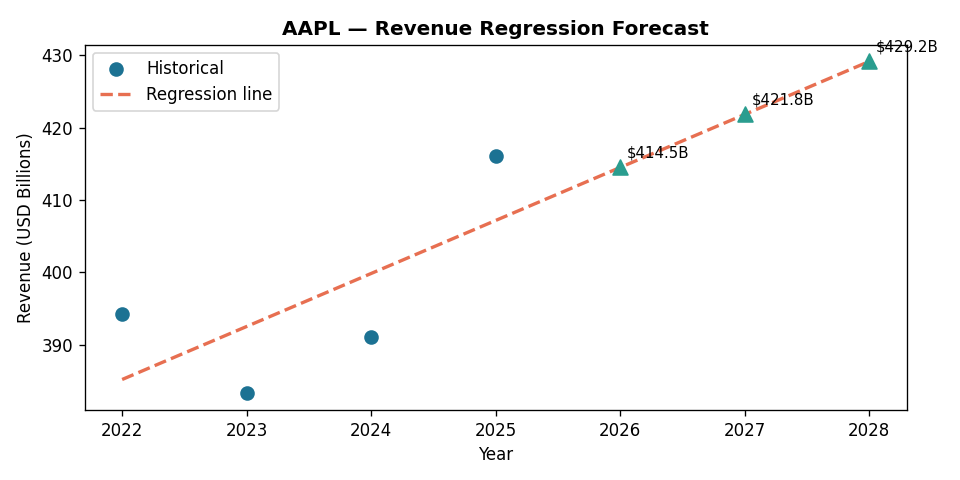

  R²: 0.451 | R²=0.451: moderate linear trend. Implies ~$7.3B revenue addition per year.


In [ ]:
@tool
def forecast_revenue_regression(ticker: str, forecast_years: int = 3) -> str:
    """
    Uses linear regression on historical annual revenue to forecast future revenues.
    Use this as an objective alternative to fixed-growth DCF assumptions — the
    regression line extrapolates the historical trend. Displays chart inline.

    Args:
        ticker:         Stock ticker symbol (e.g. 'AAPL', 'MSFT')
        forecast_years: Number of years to forecast forward (default 3)

    Returns:
        JSON string with regression statistics (r-squared, slope, p-value) and forecast values.
    """
    from IPython.display import display as ipy_display
    from scipy import stats as sp_stats

    stock = yf.Ticker(ticker.upper())
    inc   = stock.income_stmt

    if 'Total Revenue' not in inc.index:
        return json.dumps({"error": "Revenue data not available."})

    hist_years, hist_rev = [], []
    for col in reversed(inc.columns):
        yr  = int(str(col)[:4])
        rev = inc.loc['Total Revenue', col] / 1e9
        if rev > 0:                              # if-then: skip zero/negative values
            hist_years.append(yr)
            hist_rev.append(rev)

    if len(hist_years) < 3:
        return json.dumps({"error": "Insufficient historical data for regression."})

    x = np.array(hist_years)
    y = np.array(hist_rev)
    slope, intercept, r_value, p_value, std_err = sp_stats.linregress(x, y)

    last_yr   = max(hist_years)
    forecasts = {}
    for i in range(1, forecast_years + 1):      # loop: generate forecast years
        yr_f = last_yr + i
        forecasts[yr_f] = round(slope * yr_f + intercept, 2)

    # Plot and render inline
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(hist_years, hist_rev, color='#1C7293', s=60, zorder=5, label='Historical')
    x_line = np.linspace(min(hist_years), last_yr + forecast_years, 100)
    ax.plot(x_line, slope * x_line + intercept, '--', color='#E76F51', lw=2, label='Regression line')
    for yr_f, rev_f in forecasts.items():
        ax.scatter(yr_f, rev_f, color='#2A9D8F', s=80, marker='^', zorder=5)
        ax.annotate(f'${rev_f:.1f}B', (yr_f, rev_f), textcoords='offset points', xytext=(4, 6), fontsize=9)
    ax.set_xlabel('Year')
    ax.set_ylabel('Revenue (USD Billions)')
    ax.set_title(f'{ticker.upper()} — Revenue Regression Forecast', fontweight='bold')
    ax.legend()
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=120)
    buf.seek(0)
    ipy_display(Image.open(buf))
    plt.close()

    return json.dumps({
        "ticker":               ticker.upper(),
        "historical_revenue_B": dict(zip(hist_years, [round(v, 2) for v in hist_rev])),
        "regression_stats": {
            "slope_B_per_yr": round(slope,        2),
            "r_squared":      round(r_value**2,   3),
            "p_value":        round(p_value,       4),
            "std_error":      round(std_err,       3),
        },
        "forecast_B":       forecasts,
        "interpretation": (
            f"R²={round(r_value**2,3)}: "
            f"{'strong' if r_value**2 > 0.9 else 'moderate'} linear trend. "
            f"Implies ~${round(slope,1)}B revenue addition per year."
        ),
    }, indent=2)

print("Tool 8: forecast_revenue_regression")
r = json.loads(forecast_revenue_regression("AAPL", forecast_years=3))
print(f"  R²: {r['regression_stats']['r_squared']} | {r['interpretation']}")


---

## Tool 9: Altman Z-Score — Financial Distress Predictor (Score)

**Concept:** The Altman Z-Score predicts the probability of bankruptcy within 2 years
using five financial ratios combined with empirically derived weights.

```
Z = 1.2×X1 + 1.4×X2 + 3.3×X3 + 0.6×X4 + 1.0×X5
Z > 2.99 → Safe Zone | 1.81–2.99 → Grey Zone | < 1.81 → Distress Zone
```


In [ ]:
@tool
def calculate_altman_zscore(ticker: str) -> str:
    """
    Calculates the Altman Z-Score to assess financial distress risk.
    Use this as a credit risk check before finalising a valuation — a company
    in the distress zone may trade at a discount for good reason.
    Z > 2.99 = Safe, 1.81 to 2.99 = Grey Zone, below 1.81 = Distress.

    Args:
        ticker: Stock ticker symbol

    Returns:
        JSON string with Z-Score components, weighted scores, total score, and zone label.
    """
    stock = yf.Ticker(ticker.upper())
    info  = stock.info
    bal   = stock.balance_sheet
    inc   = stock.income_stmt

    def get(df, key):
        return df.loc[key].iloc[0] if key in df.index else 0

    total_assets  = get(bal, 'Total Assets')
    if total_assets == 0:
        return json.dumps({"error": "Balance sheet data unavailable."})

    curr_assets   = get(bal, 'Current Assets')
    curr_liab     = get(bal, 'Current Liabilities')
    retained_earn = get(bal, 'Retained Earnings')
    ebit          = get(inc, 'Operating Income')
    revenue       = get(inc, 'Total Revenue')
    total_liab    = get(bal, 'Total Liabilities Net Minority Interest')
    market_cap    = info.get('marketCap', 0) or 0

    # Five components — each with a zero-division guard
    X1 = (curr_assets - curr_liab) / total_assets if total_assets else 0
    X2 = retained_earn / total_assets              if total_assets else 0
    X3 = ebit          / total_assets              if total_assets else 0
    X4 = market_cap    / total_liab                if total_liab   else 0
    X5 = revenue       / total_assets              if total_assets else 0

    Z = 1.2*X1 + 1.4*X2 + 3.3*X3 + 0.6*X4 + 1.0*X5

    # if-then chain for zone classification
    if Z > 2.99:
        zone = "SAFE ZONE — low distress probability"
    elif Z >= 1.81:
        zone = "GREY ZONE — monitor carefully"
    else:
        zone = "DISTRESS ZONE — elevated bankruptcy risk"

    return json.dumps({
        "ticker":     ticker.upper(),
        "components": {
            "X1_working_capital_ratio":    round(X1, 4),
            "X2_retained_earnings_ratio":  round(X2, 4),
            "X3_ebit_to_assets":           round(X3, 4),
            "X4_mktcap_to_liabilities":    round(X4, 4),
            "X5_asset_turnover":           round(X5, 4),
        },
        "weighted_scores": {
            "1.2*X1": round(1.2*X1, 3),
            "1.4*X2": round(1.4*X2, 3),
            "3.3*X3": round(3.3*X3, 3),
            "0.6*X4": round(0.6*X4, 3),
            "1.0*X5": round(1.0*X5, 3),
        },
        "z_score": round(Z, 2),
        "zone":    zone,
    }, indent=2)

print("Tool 9: calculate_altman_zscore")
r = json.loads(calculate_altman_zscore("AAPL"))
print(f"  Z-Score: {r['z_score']} | {r['zone']}")


Tool 9: calculate_altman_zscore
  Z-Score: 10.8 | SAFE ZONE — low distress probability


---

## Tool 10: Comparable Company Multiples Analysis (EDA + Ratios)

**Concept:** DCF is only one lens. Professional analysts triangulate with market multiples —
what are similar companies trading at? This "comps" analysis uses EV/EBITDA, P/E, and P/S.

**Key programming concepts:** `for` loop over peers, pandas DataFrame for median computation,
`if-then` sector logic for default peer group selection.


In [ ]:
@tool
def comparable_company_analysis(ticker: str, peers: str = None) -> str:
    """
    Performs comparable company analysis using EV/EBITDA, P/E, and P/S multiples.
    Compares the subject company to a peer group and derives an implied valuation range.
    Use this alongside DCF to triangulate intrinsic value from a market-based perspective.

    Args:
        ticker: Subject company stock ticker
        peers:  Comma-separated peer tickers (e.g. 'MSFT,GOOGL,META').
                If None, a default sector-appropriate peer group is used.

    Returns:
        JSON string with multiples table, peer medians, and implied valuation per share.
    """
    subject = ticker.upper()
    if peers:
        peer_list = [p.strip().upper() for p in peers.split(',')]
    else:
        info_s = yf.Ticker(subject).info
        sector = info_s.get('sector', 'Technology')
        if sector == 'Technology':
            peer_list = ['MSFT', 'GOOGL', 'META', 'AMZN']
        elif sector == 'Financial Services':
            peer_list = ['JPM', 'BAC', 'GS', 'MS']
        else:
            peer_list = ['MSFT', 'GOOGL', 'AMZN', 'META']

    all_tickers = [subject] + [p for p in peer_list if p != subject]
    rows = []
    for t in all_tickers:                          # loop: fetch each ticker
        try:
            inf = yf.Ticker(t).info
            rows.append({
                'Ticker':       t,
                'EV/EBITDA':    round(inf.get('enterpriseToEbitda',           0) or 0, 1),
                'P/E':          round(inf.get('trailingPE',                   0) or 0, 1),
                'Fwd P/E':      round(inf.get('forwardPE',                    0) or 0, 1),
                'P/S':          round(inf.get('priceToSalesTrailing12Months', 0) or 0, 1),
                'Market Cap B': round((inf.get('marketCap', 0) or 0) / 1e9,           0),
            })
        except Exception:
            rows.append({'Ticker': t, 'EV/EBITDA': None, 'P/E': None,
                         'Fwd P/E': None, 'P/S': None, 'Market Cap B': None})

    df       = pd.DataFrame(rows).set_index('Ticker')
    peers_df = df.drop(subject, errors='ignore')

    # Compute peer median for each multiple using pandas
    peer_medians = {}
    for col in ['EV/EBITDA', 'P/E', 'P/S']:
        vals = peers_df[col].replace(0, np.nan).dropna()
        peer_medians[col] = round(vals.median(), 1) if len(vals) > 0 else None

    subject_info = yf.Ticker(subject).info
    ebitda   = (subject_info.get('ebitda',            0) or 0) / 1e9
    shares   = (subject_info.get('sharesOutstanding', 1) or 1) / 1e9
    net_debt = ((subject_info.get('totalDebt', 0) or 0) - (subject_info.get('totalCash', 0) or 0)) / 1e9

    implied_ivs = {}
    if peer_medians.get('EV/EBITDA') and ebitda > 0:
        implied_ev = peer_medians['EV/EBITDA'] * ebitda
        implied_ivs['via_EV_EBITDA'] = round((implied_ev - net_debt) / shares, 2) if shares > 0 else None

    return json.dumps({
        "subject":                  subject,
        "multiples_table":          df.to_dict(),
        "peer_medians":             peer_medians,
        "implied_values_per_share": implied_ivs,
        "current_price":            round(subject_info.get('currentPrice', 0) or 0, 2),
    }, indent=2)

print("Tool 10: comparable_company_analysis")
r = json.loads(comparable_company_analysis("AAPL"))
print(f"  Peer median EV/EBITDA: {r['peer_medians'].get('EV/EBITDA')} | Implied IV: {r['implied_values_per_share']}")


Tool 10: comparable_company_analysis
  Peer median EV/EBITDA: 18.0 | Implied IV: {'via_EV_EBITDA': 195.22}


---

## 🏋️ Exercise: Build Your Own Multiples Tool

Using what you learned from Tool 10, complete the stub below.
The function runs without error as-is — `pass` returns `None` until you fill it in.
Add `@tool` back **only after** you have written a complete docstring with an `Args:` section,
otherwise smolagents will throw a `DocstringParsingException` immediately.

**Your task:** Fill in the docstring and body to return EV/EBITDA, P/E, P/S, and Forward P/E.


In [ ]:
# NOTE: @tool is intentionally omitted from the stub.
# smolagents validates the docstring the moment @tool is applied,
# so add @tool back ONLY after your docstring is complete.

# NOTE: @tool   <-- uncomment this line when your docstring is complete and remove the NOTE:

def get_valuation_multiples(ticker: str) -> str:
    # YOUR DOCSTRING HERE
    # smolagents requires this exact format:
    #
    #     """One-line description of when to use this tool.
    #
    #     Args:
    #         ticker: Description of this argument
    #
    #     Returns:
    #         Description of what the tool returns
    #     """

    # YOUR CODE HERE
    # Step 1: stock = yf.Ticker(ticker.upper()); info = stock.info
    # Step 2: extract these keys from info:
    #   EV/EBITDA  -> info.get('enterpriseToEbitda', 0)
    #   P/E ratio  -> info.get('trailingPE', 0)
    #   P/S ratio  -> info.get('priceToSalesTrailing12Months', 0)
    #   Forward PE -> info.get('forwardPE', 0)
    # Step 3: return json.dumps({...}, indent=2)
    pass

# Uncomment to test once you have completed the code and restored @tool:
# print(get_valuation_multiples("AAPL"))


---

### ✅ Solution — don't peek until you've tried!

In [ ]:
@tool
def get_valuation_multiples(ticker: str) -> str:
    """
    Retrieves market valuation multiples for a company.
    Use this when comparing a company's valuation to peers or historical norms,
    or to cross-check a DCF result against current market pricing.

    Args:
        ticker: Stock ticker symbol (e.g. 'AAPL', 'MSFT')

    Returns:
        JSON string with EV/EBITDA, P/E, forward P/E, P/S, and P/B ratios.
    """
    stock = yf.Ticker(ticker.upper())
    info  = stock.info
    return json.dumps({
        "ticker":         ticker.upper(),
        "ev_to_ebitda":   round(info.get("enterpriseToEbitda",           0) or 0, 2),
        "pe_ratio":       round(info.get("trailingPE",                   0) or 0, 2),
        "forward_pe":     round(info.get("forwardPE",                    0) or 0, 2),
        "price_to_sales": round(info.get("priceToSalesTrailing12Months", 0) or 0, 2),
        "price_to_book":  round(info.get("priceToBook",                  0) or 0, 2),
    }, indent=2)

print("Solution — AAPL multiples:")
print(get_valuation_multiples("AAPL"))


Solution — AAPL multiples:
{
  "ticker": "AAPL",
  "ev_to_ebitda": 25.82,
  "pe_ratio": 33.48,
  "forward_pe": 28.98,
  "price_to_sales": 8.99,
  "price_to_book": 46.11
}


---

## Tool 11: Moving Average Price Trend (Moving Averages)

**Concept:** The 50-day and 200-day moving averages smooth short-term price noise to reveal
the underlying trend. A **Golden Cross** (50MA crosses above 200MA) is bullish;
a **Death Cross** is bearish.


Tool 11: calculate_moving_averages


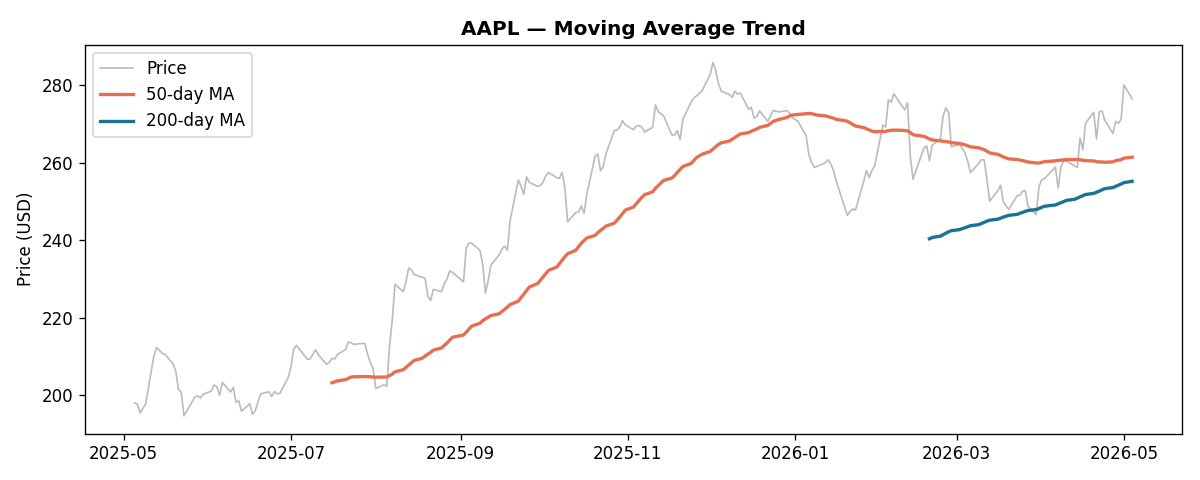

  Trend: BULLISH: short MA above long MA | No recent crossover detected


In [ ]:
@tool
def calculate_moving_averages(ticker: str, short_window: int = 50, long_window: int = 200) -> str:
    """
    Calculates and plots 50-day and 200-day moving averages for a stock's closing price.
    Detects Golden Cross (bullish) and Death Cross (bearish) signals in the last 30 days.
    Use this to assess the price trend context alongside fundamental valuation.
    Displays the chart inline and returns trend classification.

    Args:
        ticker:       Stock ticker symbol (e.g. 'AAPL', 'MSFT')
        short_window: Short-period moving average in days (default 50)
        long_window:  Long-period moving average in days (default 200)

    Returns:
        JSON string with latest MA values, trend classification, and cross signal.
    """
    from IPython.display import display as ipy_display

    stock = yf.Ticker(ticker.upper())
    hist  = stock.history(period='1y')

    if len(hist) < long_window:
        return json.dumps({"error": f"Need at least {long_window} trading days of history."})

    # Pandas rolling means
    hist[f'MA{short_window}'] = hist['Close'].rolling(window=short_window).mean()
    hist[f'MA{long_window}']  = hist['Close'].rolling(window=long_window).mean()

    latest_price = round(hist['Close'].iloc[-1], 2)
    latest_short = round(hist[f'MA{short_window}'].iloc[-1], 2)
    latest_long  = round(hist[f'MA{long_window}'].iloc[-1],  2)

    # Loop backwards to find the most recent crossover
    cross_signal = "No recent crossover detected"
    for i in range(len(hist) - 1, max(len(hist) - 30, 0), -1):
        prev = hist[f'MA{short_window}'].iloc[i-1] - hist[f'MA{long_window}'].iloc[i-1]
        curr = hist[f'MA{short_window}'].iloc[i]   - hist[f'MA{long_window}'].iloc[i]
        if pd.isna(prev) or pd.isna(curr):
            continue
        if prev < 0 and curr >= 0:
            cross_signal = f"GOLDEN CROSS on {str(hist.index[i])[:10]} — bullish"
            break
        elif prev > 0 and curr <= 0:
            cross_signal = f"DEATH CROSS on {str(hist.index[i])[:10]} — bearish"
            break

    trend = "BULLISH: short MA above long MA" if latest_short > latest_long else "BEARISH: short MA below long MA"

    # Plot and render inline
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(hist.index, hist['Close'],             color='#aaaaaa', lw=1, alpha=0.8, label='Price')
    ax.plot(hist.index, hist[f'MA{short_window}'], color='#E76F51', lw=2, label=f'{short_window}-day MA')
    ax.plot(hist.index, hist[f'MA{long_window}'],  color='#1C7293', lw=2, label=f'{long_window}-day MA')
    ax.set_title(f'{ticker.upper()} — Moving Average Trend', fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    plt.tight_layout()

    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=120)
    buf.seek(0)
    ipy_display(Image.open(buf))
    plt.close()

    return json.dumps({
        "ticker":              ticker.upper(),
        "current_price":       latest_price,
        f"ma_{short_window}d": latest_short,
        f"ma_{long_window}d":  latest_long,
        "trend":               trend,
        "cross_signal":        cross_signal,
    }, indent=2)

print("Tool 11: calculate_moving_averages")
r = json.loads(calculate_moving_averages("AAPL"))
print(f"  Trend: {r['trend']} | {r['cross_signal']}")


---

## Tool 12: Investment Memo Generator (Orchestration Tool)

**Concept:** The culminating tool synthesises all upstream outputs into a structured
investment memo — the standard deliverable of a buy-side equity analyst.


In [ ]:
@tool
def generate_investment_memo(
    ticker: str,
    wacc: float = 0.10,
    terminal_growth_rate: float = 0.025,
) -> str:
    """
    Runs the full valuation pipeline and generates a structured investment memo
    with executive summary, DCF output, risk factors, and BUY/HOLD/SELL recommendation.
    Use this as the FINAL step after individual tools have been explored.

    Args:
        ticker:               Stock ticker symbol
        wacc:                 WACC assumption as decimal (default 0.10 = 10%)
        terminal_growth_rate: Terminal growth rate as decimal (default 0.025 = 2.5%)

    Returns:
        Formatted markdown investment memo as a string.
    """
    stock = yf.Ticker(ticker.upper())
    info  = stock.info
    cf    = stock.cashflow
    inc   = stock.income_stmt

    op_cf    = cf.loc['Operating Cash Flow'].iloc[0] if 'Operating Cash Flow' in cf.index else 0
    capex    = cf.loc['Capital Expenditure'].iloc[0]  if 'Capital Expenditure'  in cf.index else 0
    revenue  = inc.loc['Total Revenue'].iloc[0]       if 'Total Revenue'         in inc.index else 0
    base_fcf = (op_cf + capex) / 1e9
    debt     = (info.get('totalDebt',         0) or 0) / 1e9
    cash_val = (info.get('totalCash',         0) or 0) / 1e9
    shares   = (info.get('sharesOutstanding', 1) or 1) / 1e9
    price    = info.get('currentPrice', 0) or 0
    name     = info.get('longName', ticker.upper())
    beta     = info.get('beta', 1.0) or 1.0

    # Inline DCF
    fcf, pv_fcfs = base_fcf, []
    for yr in range(1, 6):
        fcf *= (1 + (0.12 if yr <= 3 else 0.07))
        pv_fcfs.append(fcf / (1 + wacc) ** yr)
    tv    = fcf * (1 + terminal_growth_rate) / (wacc - terminal_growth_rate)
    pv_tv = tv / (1 + wacc) ** 5
    ev    = sum(pv_fcfs) + pv_tv
    eq_v  = ev - debt + cash_val
    iv    = round(eq_v / shares, 2) if shares > 0 else 0
    upside = round((iv - price) / price * 100, 1) if price else 0
    signal = "BUY" if upside > 10 else ("SELL" if upside < -10 else "HOLD")
    direction = "upside" if upside > 0 else "downside"

    return f"""
## Investment Memo — {name} ({ticker.upper()})

---

### Executive Summary
{name} is valued at **${iv:.2f}/share** on our base-case DCF
(WACC: {wacc*100:.1f}%, TGR: {terminal_growth_rate*100:.1f}%).
Current market price: **${price:.2f}** → implied **{upside:+.1f}% {direction}**.

**Recommendation: {signal}**

---

### Key Financials (TTM)
| Metric | Value |
|---|---|
| Revenue | ${revenue/1e9:.1f}B |
| Free Cash Flow | ${base_fcf:.1f}B |
| Total Debt | ${debt:.1f}B |
| Cash | ${cash_val:.1f}B |
| Beta | {beta:.2f} |

### DCF Summary
| Component | USD Billions |
|---|---|
| PV of FCFs (5yr) | ${sum(pv_fcfs):.1f}B |
| PV of Terminal Value | ${pv_tv:.1f}B |
| Enterprise Value | ${ev:.1f}B |
| Net Debt | ${debt - cash_val:.1f}B |
| **Equity Value** | **${eq_v:.1f}B** |
| **Intrinsic Value/Share** | **${iv:.2f}** |

**Assumptions:** WACC {wacc*100:.1f}% · TGR {terminal_growth_rate*100:.1f}%
· FCF growth 12% (Y1-3) → 7% (Y4-5)

---

### Risk Factors
- Beta {beta:.2f}: {'above' if beta > 1 else 'below'}-average market sensitivity
- Terminal value = ~{round(pv_tv/ev*100)}% of enterprise value — highly assumption-sensitive
- WACC ±1% shifts intrinsic value by approximately 10-20%

---
*AI-generated memo. For educational purposes only. Not investment advice.*
"""

print("Tool 12: generate_investment_memo ✅")
print("All 12 tools defined successfully.")


Tool 12: generate_investment_memo ✅
All 12 tools defined successfully.


---

# Part 2: Single-Agent ReAct Demo

Before building the full two-agent orchestration, let's see one agent use multiple tools
in a **ReAct loop** — reasoning dynamically about which tool to call at each step.

```
THINK → "I need financials first"         ACT → fetch_and_summarise_financials("MSFT")
THINK → "Now calculate WACC from CAPM"   ACT → calculate_capm_wacc("MSFT")
THINK → "Run DCF with this WACC"         ACT → run_dcf_model("MSFT", wacc=derived_wacc)
THINK → "Stress-test assumptions"        ACT → run_sensitivity_analysis("MSFT")
THINK → "Check distress risk"            ACT → calculate_altman_zscore("MSFT")
THINK → "Synthesise everything"          ACT → generate_investment_memo("MSFT")
FINAL ANSWER → Structured memo
```

**The agent is not following a script.** It reasons about what to do next based on what it has already learned.


In [ ]:
valuation_agent = CodeAgent(
    tools=[
        fetch_and_summarise_financials,
        plot_revenue_and_margins,
        calculate_profitability_ratios,
        calculate_liquidity_leverage,
        calculate_capm_wacc,
        run_dcf_model,
        run_sensitivity_analysis,
        forecast_revenue_regression,
        calculate_altman_zscore,
        comparable_company_analysis,
        calculate_moving_averages,
        generate_investment_memo,
    ],
    model=model,
    verbosity_level=LogLevel.INFO,
    max_steps=20,
    additional_authorized_imports=[
        "numpy", "pandas", "matplotlib.pyplot", "matplotlib.ticker",
        "matplotlib", "scipy.stats", "scipy", "json", "io", "PIL", "PIL.Image",
    ],
)
print("✅ Valuation agent ready — 12 tools loaded.")


✅ Valuation agent ready — 12 tools loaded.


╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Perform a complete valuation analysis for Microsoft (MSFT):                                                     │
│ 1. Fetch and summarise the financials                                                                           │
│ 2. Plot the revenue and margin trend                                                                            │
│ 3. Calculate the CAPM-derived WACC                                                                              │
│ 4. Run the DCF model using that WACC                                                                            │
│ 5. Run sensitivity analysis around the base case                                                                │
│ 6. Check the Altman Z-Score for distress risk                                                                   │
│ 7. Generate the full investment memo with recommendation                                                        │
│                                                                                                                 │
╰─ OpenAIModel - gemini-2.5-flash ────────────────────────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  financials_summary = fetch_and_summarise_financials(ticker="MSFT")                                               
  print(financials_summary)                                                                                        
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
{
  "ticker": "MSFT",
  "company_name": "Microsoft Corporation",
  "sector": "Technology",
  "industry": "Software - Infrastructure",
  "revenue_by_year_B": {
    "2025": 281.72,
    "2024": 245.12,
    "2023": 211.92,
    "2022": 198.27
  },
  "revenue_descriptive_stats": {
    "mean_B": 234.26,
    "std_B": 37.26,
    "min_B": 198.27,
    "max_B": 281.72,
    "growth_pct_latest": 14.9
  },
  "free_cash_flow_ttm_B": 71.61,
  "net_income_ttm_B": 101.83,
  "total_debt_B": 125.43,
  "cash_B": 78.23,
  "shares_outstanding_B": 7.4284,
  "current_price": 419.44,
  "market_cap_B": 3115.86,
  "beta": 1.09,
  "ebitda_B": 184.46
}

Out: None

[Step 1: Duration 10.59 seconds| Input tokens: 3,957 | Output tokens: 30]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  revenue_margin_plot = plot_revenue_and_margins(ticker="MSFT")                                                    
  print(revenue_margin_plot)                                                                                       
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

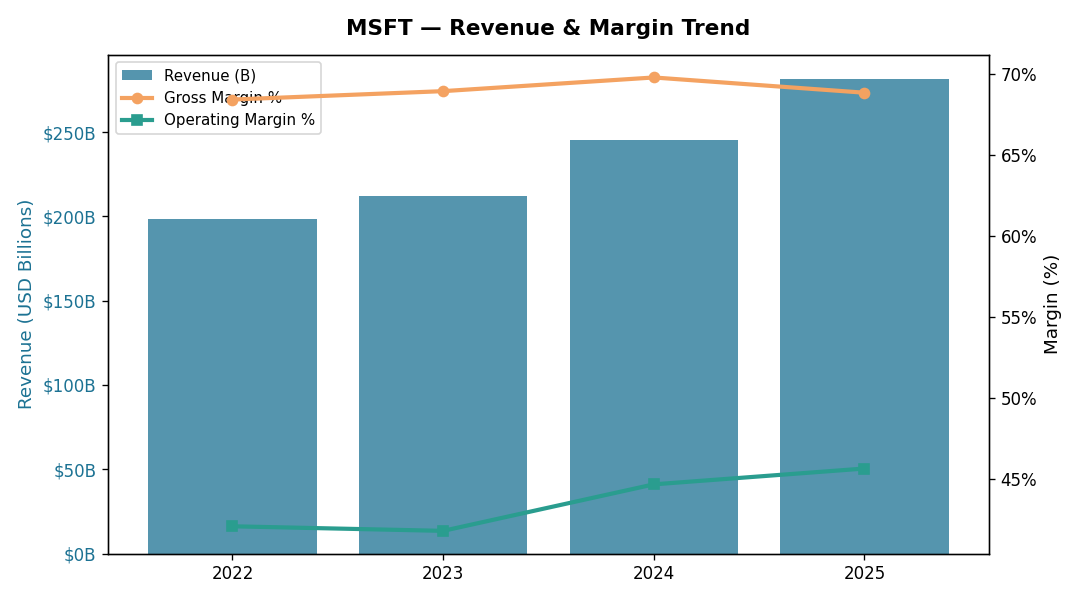

Execution logs:
Gross margin expanded from 68.4% to 68.8% over 4 years. Revenue grew from $198.3B to $281.7B.

Out: None

[Step 2: Duration 1.73 seconds| Input tokens: 8,384 | Output tokens: 85]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 3 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  wacc_calculation = calculate_capm_wacc(ticker="MSFT")                                                            
  print(wacc_calculation)                                                                                          
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
{
  "ticker": "MSFT",
  "beta": 1.09,
  "risk_free_rate_pct": 4.5,
  "equity_risk_premium_pct": 5.5,
  "cost_of_equity_pct": 10.51,
  "cost_of_debt_pretax_pct": 1.9,
  "cost_of_debt_aftertax_pct": 1.5,
  "weight_equity_pct": 96.1,
  "weight_debt_pct": 3.9,
  "wacc_pct": 10.16,
  "note": "WACC derived from CAPM + market capital structure. Use as DCF discount rate."
}

Out: None

[Step 3: Duration 1.78 seconds| Input tokens: 12,992 | Output tokens: 171]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 4 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Error in generating model output:
Error code: 503 - [{'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in 
demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}\]

[Step 4: Duration 12.23 seconds]

AgentGenerationError: Error in generating model output:
Error code: 503 - [{'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}]

In [ ]:
result = valuation_agent.run("""
Perform a complete valuation analysis for Microsoft (MSFT):
1. Fetch and summarise the financials
2. Plot the revenue and margin trend
3. Calculate the CAPM-derived WACC
4. Run the DCF model using that WACC
5. Run sensitivity analysis around the base case
6. Check the Altman Z-Score for distress risk
7. Generate the full investment memo with recommendation
""")
print(result)


---

# Part 3: Orchestration — Two Agents + Gradio Interface

## Architecture

```
┌────────────────────────────────────────────────────────────────────┐
│                    TWO-AGENT ORCHESTRATION                          │
│                                                                     │
│  USER QUERY (Gradio UI)                                             │
│       │                                                             │
│       ▼                                                             │
│  ┌──────────────────────────────────────┐                          │
│  │  AGENT 1: FUNDAMENTAL ANALYST        │                          │
│  │  Tools 1,2,3,4,9,10,11               │                          │
│  │  → Produces: company snapshot        │                          │
│  └─────────────────┬────────────────────┘                          │
│                    │ snapshot passed as context                     │
│                    ▼                                                │
│  ┌──────────────────────────────────────┐                          │
│  │  AGENT 2: VALUATION MODELLER         │                          │
│  │  Tools 5,6,7,8,12                    │                          │
│  │  → Produces: investment memo         │                          │
│  └──────────────────────────────────────┘                          │
│                    │                                                │
│                    ▼                                                │
│  GRADIO UI: Displays memo + charts                                  │
└────────────────────────────────────────────────────────────────────┘
```


In [ ]:
import gradio as gr

# ── Agent 1: Fundamental Analyst ──────────────────────────────────────────
fundamental_agent = CodeAgent(
    tools=[
        fetch_and_summarise_financials,
        plot_revenue_and_margins,
        calculate_profitability_ratios,
        calculate_liquidity_leverage,
        calculate_altman_zscore,
        comparable_company_analysis,
        calculate_moving_averages,
    ],
    model=model,
    verbosity_level=LogLevel.ERROR,
    max_steps=14,
    additional_authorized_imports=[
        "numpy", "pandas", "matplotlib.pyplot", "matplotlib.ticker",
        "matplotlib", "json", "io", "PIL", "PIL.Image",
    ],
)

# ── Agent 2: Valuation Modeller ───────────────────────────────────────────
valuation_modeller = CodeAgent(
    tools=[
        calculate_capm_wacc,
        run_dcf_model,
        run_sensitivity_analysis,
        forecast_revenue_regression,
        generate_investment_memo,
    ],
    model=model,
    verbosity_level=LogLevel.ERROR,
    max_steps=12,
    additional_authorized_imports=[
        "numpy", "pandas", "matplotlib.pyplot", "matplotlib.ticker",
        "matplotlib", "scipy.stats", "scipy", "json", "io", "PIL", "PIL.Image",
    ],
)

print("✅ Agent 1: Fundamental Analyst — 7 tools")
print("✅ Agent 2: Valuation Modeller  — 5 tools")


In [ ]:
def run_two_agent_valuation(
    ticker: str,
    wacc_override: float = None,
    tgr_override: float = None,
) -> tuple:
    """
    Orchestrates two agents sequentially to produce a full valuation analysis.
    Agent 1 handles fundamental analysis; Agent 2 handles quantitative modelling.
    Returns (combined_memo, status_log).
    """
    ticker = ticker.strip().upper()
    if not ticker:
        return "Please enter a ticker symbol.", "No ticker provided."

    log = []

    # ── Agent 1 ─────────────────────────────────────────────────
    log.append(f"🔍 Agent 1: Analysing {ticker} fundamentals...")
    try:
        fundamental_result = fundamental_agent.run(f"""
Analyse {ticker}:
1. Fetch and summarise the financials
2. Plot the revenue and margin trend
3. Calculate profitability ratios (gross margin, net margin, ROE, ROA)
4. Calculate liquidity and leverage ratios
5. Calculate the Altman Z-Score
6. Run comparable company analysis
7. Check the 50/200-day moving average trend

Summarise key findings in clear bullet points. Flag any risks or red flags clearly.
""")
    except Exception as e:
        fundamental_result = f"Fundamental analysis error: {e}"
    log.append("✅ Agent 1 complete.")

    # ── Agent 2 ─────────────────────────────────────────────────
    log.append(f"📊 Agent 2: Building valuation model for {ticker}...")
    wacc_instr = f"Use WACC of {wacc_override:.1%}." if wacc_override else "Calculate WACC using CAPM first."
    tgr_instr  = f"Use terminal growth rate of {tgr_override:.1%}." if tgr_override else "Use terminal growth rate of 2.5%."

    try:
        valuation_result = valuation_modeller.run(f"""
You are valuing {ticker}.

CONTEXT FROM AGENT 1 (FUNDAMENTAL ANALYSIS):
{fundamental_result}

INSTRUCTIONS:
1. {wacc_instr}
2. {tgr_instr}
3. Run the DCF model with these assumptions
4. Run sensitivity analysis (WACC x TGR matrix)
5. Forecast revenue using regression
6. Generate the full investment memo

Present a clear BUY / HOLD / SELL recommendation with the key numbers.
""")
    except Exception as e:
        valuation_result = f"Valuation model error: {e}"
    log.append("✅ Agent 2 complete.")
    log.append("📋 Full analysis ready.")

    combined = f"""# Valuation Analysis: {ticker}

---

## 🔍 Fundamental Analysis (Agent 1)

{fundamental_result}

---

## 📊 Valuation Model (Agent 2)

{valuation_result}

---
*Generated by Two-Agent Valuation System · Gemini 2.5 Flash · For educational purposes only · Not investment advice.*
"""
    return combined, "\n".join(log)

print("✅ Orchestration function ready.")


---

## Gradio Interface

A user-friendly interface that lets any analyst run the full two-agent pipeline
by entering a ticker and clicking a button — no code required.


In [ ]:
def gradio_valuation(ticker, wacc_pct, tgr_pct, use_custom):
    wacc = (wacc_pct / 100) if use_custom else None
    tgr  = (tgr_pct  / 100) if use_custom else None
    return run_two_agent_valuation(ticker, wacc, tgr)

with gr.Blocks(
    title="ValuAI — Corporate Valuation Agent",
    theme=gr.themes.Soft(),
    css="""
        .header { text-align:center; padding:16px; background:#0d1f3c;
                  color:white; border-radius:8px; margin-bottom:16px; }
        .subhead { color:#666; font-size:13px; text-align:center; margin-bottom:20px; }
        .disclaimer { color:#999; font-size:11px; margin-top:8px; }
    """
) as demo:

    gr.HTML("""
        <div class="header">
            <h2>🏦 ValuAI — Corporate Valuation AI Agent</h2>
        </div>
        <p class="subhead">
            Two specialised AI agents · smolagents · Google Gemini 2.5 Flash<br>
            Enter any US-listed ticker for a full DCF valuation pipeline
        </p>
    """)

    with gr.Row():
        with gr.Column(scale=1):
            ticker_input = gr.Textbox(
                label="📈 Ticker Symbol",
                placeholder="e.g. AAPL, MSFT, TSLA, JPM",
                value="AAPL",
            )
            use_custom = gr.Checkbox(label="🔧 Override WACC & TGR", value=False)
            with gr.Group(visible=False) as custom_grp:
                wacc_slider = gr.Slider(minimum=6, maximum=18, step=0.5, value=10, label="WACC (%)")
                tgr_slider  = gr.Slider(minimum=1, maximum=5,  step=0.5, value=2.5, label="Terminal Growth Rate (%)")

            run_btn = gr.Button("▶  Run Full Valuation", variant="primary", size="lg")

            gr.Examples(
                examples=[["AAPL"], ["MSFT"], ["TSLA"], ["AMZN"], ["NVDA"], ["JPM"]],
                inputs=[ticker_input],
                label="Quick examples",
            )

            status_box = gr.Textbox(label="⚙️ Agent Status", lines=5, interactive=False)
            gr.HTML('<p class="disclaimer">⚠️ For educational purposes only. Not investment advice.</p>')

        with gr.Column(scale=2):
            output_box = gr.Markdown(
                value="*Enter a ticker and click Run Full Valuation to begin.*",
                label="Investment Analysis",
            )

    use_custom.change(fn=lambda x: gr.update(visible=x), inputs=[use_custom], outputs=[custom_grp])
    run_btn.click(
        fn=gradio_valuation,
        inputs=[ticker_input, wacc_slider, tgr_slider, use_custom],
        outputs=[output_box, status_box],
    )

print("✅ Gradio interface defined. Launching...")
demo.launch(share=True, debug=False)


---

# Discussion: Traditional vs. Agentic Approach

## How This Is Done Traditionally

| Task | Traditional Tool | Time Required |
|---|---|---|
| Pull financial statements | SEC EDGAR / Bloomberg Terminal | 30–60 min |
| Build DCF model | Excel (hand-coded formulas) | 2–4 hours |
| Sensitivity analysis | Excel data tables | 30 min |
| Comparable company analysis | Excel + manual web research | 1–2 hours |
| Altman Z-Score calculation | Excel formula | 15 min |
| Write investment memo | Word / PowerPoint | 1–2 hours |
| **Total per company** | **Excel + Word + Bloomberg** | **5–9 hours** |

With the two-agent system above: **under 3 minutes per company.**

---

## Pros and Cons

### ✅ Advantages of the Agentic Approach

**Speed and scale.** An analyst can screen 50 companies in the time it previously took
to analyse one. This fundamentally changes what is possible in deal screening and portfolio monitoring.

**Reproducibility.** Every tool call is deterministic given the same inputs.
The logic is transparent and auditable — unlike a shared Excel file where a number may
have been hard-coded years ago and never updated.

**Natural language interface.** Portfolio managers and executives can query the Gradio
interface without knowing Python or financial modelling. This democratises access to rigorous analysis.

**Error reduction.** Circular reference bugs, formula drift, and copy-paste errors —
the leading causes of Excel valuation errors — are eliminated. Each tool is independently testable.

### ❌ Limitations and Risks

**Data quality dependency.** yfinance lags official filings and may contain errors for
smaller or international companies. Production systems require premium providers
(Bloomberg, Refinitiv, FactSet).

**Model sensitivity.** DCF outputs are highly sensitive to WACC and TGR assumptions.
A 1% change in WACC can shift intrinsic value by 15–20%. The sensitivity tool makes
this visible, but non-expert users may still take point estimates at face value.

**LLM orchestration errors.** Unlike an Excel formula that always returns the same result,
an LLM agent can occasionally reason incorrectly about which tool to call next.
The tools themselves are deterministic; the orchestration reasoning is probabilistic.

**Missing qualitative factors.** Valuation is not purely quantitative. Management quality,
competitive moats, regulatory risk, and macro conditions cannot be captured in financial
data tools alone.

---

## Raw LLM vs. Tool-Grounded Agent: AI Risk Management

| Risk | Raw LLM (no tools) | Agent with Tools |
|---|---|---|
| **Hallucinated numbers** | HIGH — LLM invents financial data | LOW — all numbers from verified APIs |
| **Stale data** | HIGH — training data cutoff | LOW — yfinance fetches live data |
| **Unverifiable reasoning** | HIGH — black box output | LOW — full ReAct trace visible |
| **Assumption transparency** | LOW — implicit | HIGH — WACC, TGR, growth all explicit |
| **Auditability** | None | Full tool-call trace at every step |

This is the core principle of **AI risk management in finance**: ground the LLM in tools
so it cannot fabricate. The LLM handles reasoning and synthesis; the tools handle
data retrieval and calculation. Neither alone is sufficient.

---

## Responsible AI Considerations

1. **Disclosure.** Any AI-generated analysis used in an investment context must be disclosed.
   Regulators (SEC, FCA, MAS) are actively developing guidance on AI use in investment management.

2. **Human oversight.** The Gradio interface is a *starting point* for analyst review,
   not a final deliverable. Every output must be reviewed by a qualified professional.

3. **Model limitations.** The DCF uses simplified two-stage growth assumptions.
   A production system would incorporate earnings guidance, consensus estimates, and
   scenario-specific adjustments reviewed by a human analyst.

4. **Data provenance.** Always verify yfinance outputs against SEC filings (10-K, 10-Q)
   for any material investment decision.

---

## What's Next

- **Earnings transcript NLP** — add a tool that reads earnings call transcripts
  and extracts forward guidance to replace static growth assumptions
- **News sentiment integration** — real-time sentiment as a qualitative signal
  alongside the quantitative DCF
- **Portfolio-level analysis** — extend to multi-company portfolio construction
  with correlation, diversification, and risk attribution
- **Persistent memory** — save analysis history to a database so analysts can
  track how a company's valuation evolves quarter over quarter
- **Guardrail layer** — add input validation (WACC bounds, TGR sanity checks)
  and output sanity checks before surfacing results to the user


In [ ]:
# --- FINAL CLEAN PUSH to github (manual update) ---
import os, shutil
from google.colab import userdata, _message, drive
import pandas as pd

# 0. Mount Google Drive
drive.mount('/content/drive')

# 1. Pull credentials from Secrets
GIT_TOKEN    = userdata.get('Agent_for_corp_val')
GIT_USERNAME = userdata.get('GITHUB_USER')
GIT_EMAIL    = userdata.get('GITHUB_EMAIL')
GIT_REPO     = userdata.get('GITHUB_REPO')

# 2. The exact notebook filename and path on Drive
NOTEBOOK_NAME = "Agents for Corporate Valuation and Financial Modelling-Team 3.ipynb"
NOTEBOOK_PATH = f"/content/drive/MyDrive/Colab Notebooks/TP02/{NOTEBOOK_NAME}"

# 3. Build the secure URL
GIT_PATH = f"https://{GIT_TOKEN}@github.com/{GIT_USERNAME}/{GIT_REPO}.git"

# 4. Force save the notebook before pushing
_message.blocking_request('save_notebook')
print("✅ Notebook saved")

# 5. Clone the repo into a temp folder (preserves all existing files)
CLONE_DIR = "/content/repo_sync"
if os.path.exists(CLONE_DIR):
    !rm -rf {CLONE_DIR}                                 # fresh clone every time

!git clone {GIT_PATH} {CLONE_DIR}

# 6. Configure git identity inside the cloned repo
!git -C {CLONE_DIR} config user.email "{GIT_EMAIL}"
!git -C {CLONE_DIR} config user.name "{GIT_USERNAME}"

# 7. Copy ONLY the target notebook into the cloned repo
shutil.copy(NOTEBOOK_PATH, f"{CLONE_DIR}/{NOTEBOOK_NAME}")
print(f"✅ Copied: {NOTEBOOK_NAME}")

# 8. Stage ONLY the notebook — nothing else is touched
!git -C {CLONE_DIR} add "{NOTEBOOK_NAME}"

# 9. Commit and push only if there are actual changes
result = !git -C {CLONE_DIR} diff --cached --quiet; echo $?
if result[0].strip() != '0':
    timestamp = pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')
    !git -C {CLONE_DIR} commit -m "TP02 Submission Update - {timestamp}"
    !git -C {CLONE_DIR} push origin main
    print(f"\n✅ Push Successful! View your work here: https://github.com/{GIT_USERNAME}/{GIT_REPO}")
else:
    print("\n⚠️ No changes detected — nothing pushed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Notebook saved
Cloning into '/content/repo_sync'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 1), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 259.19 KiB | 5.29 MiB/s, done.
Resolving deltas: 100% (1/1), done.
✅ Copied: Agents for Corporate Valuation and Financial Modelling-Team 3.ipynb
[main b587295] TP02 Submission Update - 2026-05-06 14:29
 1 file changed, 1 insertion(+), 1 deletion(-)
 rewrite Agents for Corporate Valuation and Financial Modelling-Team 3.ipynb (92%)
Enumerating objects: 5, done.
Counting objects: 100% (5/5), done.
Delta compression using up to 2 threads
Compressing objects: 100% (3/3), done.
Writing objects: 100% (3/3), 1.09 KiB | 111.00 KiB/s, done.
Total 3 (delta 2), reused 0 (delta 0), pack-reused